In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd

In [2]:
import re

def parse_seismogram_out(file_path):
    results = []
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    blocks = re.split(
        r'=+\s*Running test with OMP_NUM_THREADS = (\d+)\s*=+',
        content
    )
    
    for i in range(1, len(blocks), 2):
        threads = int(blocks[i])
        block = blocks[i+1]
        
        # NFREQ (only once per block)
        nfreq_match = re.search(r'NFREQ\s*=\s*(\d+)', block)
        n_freq = int(nfreq_match.group(1)) if nfreq_match else None
        
        # Find ALL runs
        runs = re.findall(
            r'Wave zero-point\s*:\s*([-+eE0-9.]+).*?'
            r'Seismogram first coeff\s*:\s*([-+0-9.eE]+),\s*([-+0-9.eE]+),\s*([-+0-9.eE]+),\s*([-+0-9.eE]+).*?'
            r'Elapsed time for FFTs\s*:\s*([0-9.]+).*?'
            r'Elapsed time without FFTs\s*:\s*([0-9.]+).*?'
            r'Elapsed time\s*:\s*([0-9.]+).*?'
            r'Checksum\s*:\s*([0-9.eE+-]+)',
            block,
            re.DOTALL
        )
        
        for run in runs:
            wave_zero = float(run[0])
            coeffs = list(map(float, run[1:5]))
            fft_time = float(run[5])
            no_fft_time = float(run[6])
            total_time = float(run[7])
            checksum = float(run[8])
            
            results.append({
                'threads': threads,
                'n_freq': n_freq,
                'wave_zero': wave_zero,
                'seismogram_coeff': coeffs,
                'fft_time': fft_time,
                'no_fft_time': no_fft_time,
                'total_time': total_time,
                'checksum': checksum
            })
    
    return results

In [3]:
data = parse_seismogram_out('mp2.out')
for entry in data:
    print(entry)

{'threads': 1, 'n_freq': 65536, 'wave_zero': -1.9183e-08, 'seismogram_coeff': [-0.014087, -0.017407, -0.019272, -0.019317], 'fft_time': 0.1006, 'no_fft_time': 0.8894, 'total_time': 0.9899, 'checksum': 23.2912755963295}
{'threads': 1, 'n_freq': 65536, 'wave_zero': -1.9183e-08, 'seismogram_coeff': [-0.014087, -0.017407, -0.019272, -0.019317], 'fft_time': 0.1005, 'no_fft_time': 0.8904, 'total_time': 0.9909, 'checksum': 23.2912755963295}
{'threads': 1, 'n_freq': 65536, 'wave_zero': -1.9183e-08, 'seismogram_coeff': [-0.014087, -0.017407, -0.019272, -0.019317], 'fft_time': 0.1004, 'no_fft_time': 0.89, 'total_time': 0.9904, 'checksum': 23.2912755963295}
{'threads': 1, 'n_freq': 65536, 'wave_zero': -1.9183e-08, 'seismogram_coeff': [-0.014087, -0.017407, -0.019272, -0.019317], 'fft_time': 0.1004, 'no_fft_time': 0.8896, 'total_time': 0.9899, 'checksum': 23.2912755963295}
{'threads': 1, 'n_freq': 65536, 'wave_zero': -1.9183e-08, 'seismogram_coeff': [-0.014087, -0.017407, -0.019272, -0.019317], 'f

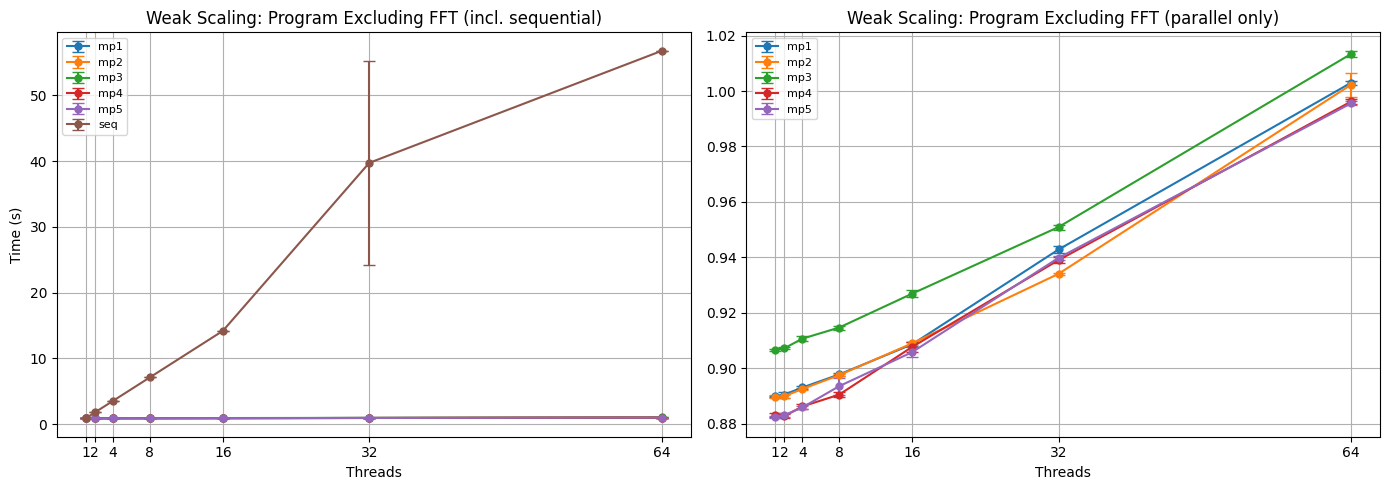

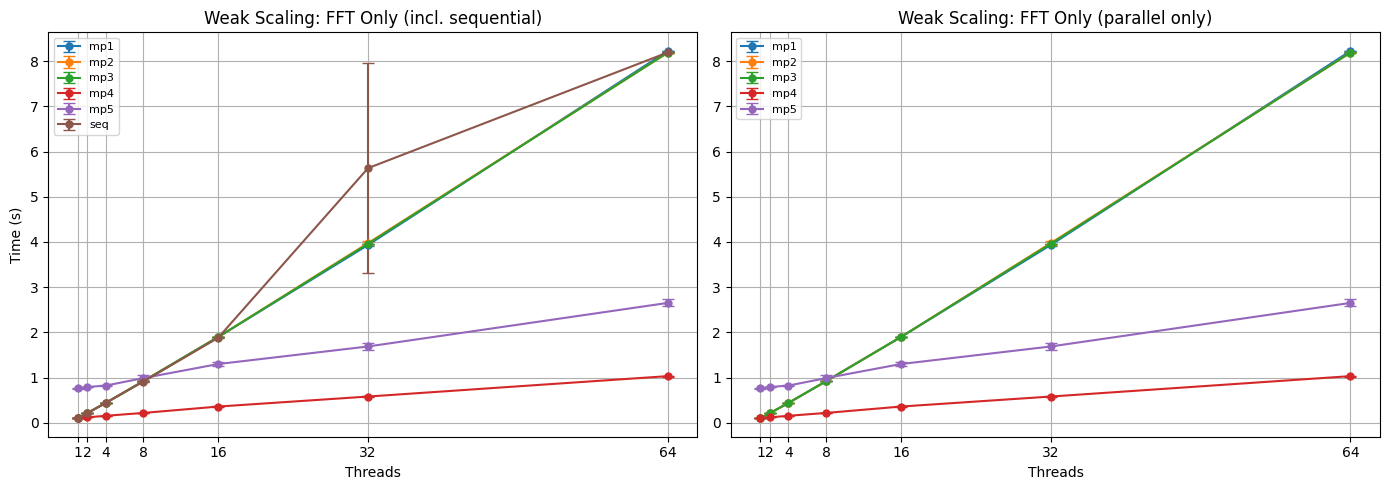

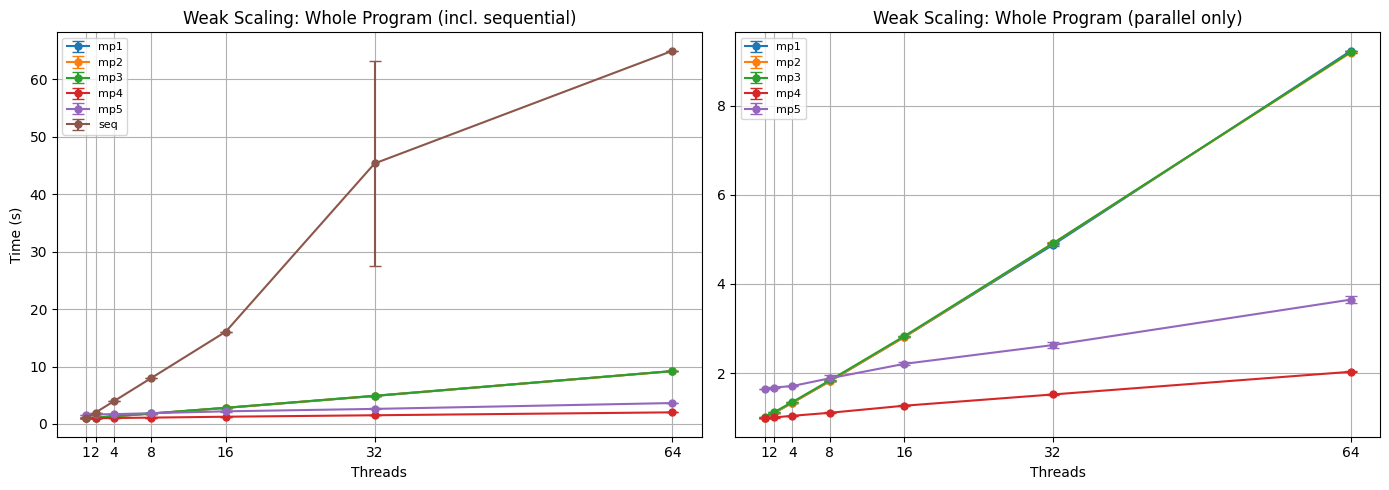

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

# List of output files
files = sorted(glob.glob('mp*.out')) + ['seq.out']

# Dictionary to hold data per code version
data_versions = {}

for f in files:
    version_name = f.split('.')[0]
    data = parse_seismogram_out(f)  # make sure this function works
    df = pd.DataFrame(data)
    
    if df.empty:
        print(f"Warning: {f} is empty, skipping.")
        continue
    
    grouped = df.groupby('threads').agg({
        'fft_time': ['mean', 'std'],
        'no_fft_time': ['mean', 'std'],
        'total_time': ['mean', 'std']
    }).reset_index()
    grouped.columns = ['threads', 'fft_mean', 'fft_std', 
                       'no_fft_mean', 'no_fft_std', 
                       'total_mean', 'total_std']
    
    data_versions[version_name] = grouped

# Plot function with safe ylim
def plot_metric_subplots(metric_mean, metric_std, ylabel, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Subplot 1: include sequential
    for version, df in data_versions.items():
        axes[0].errorbar(df['threads'], df[metric_mean], yerr=df[metric_std], 
                         fmt='-o', capsize=4, markersize=5, label=version)
    axes[0].set_title(title + " (incl. sequential)")
    axes[0].set_xlabel("Threads")
    axes[0].set_ylabel(ylabel)
    axes[0].grid(True)
    axes[0].set_xticks(df['threads'])
    axes[0].legend(fontsize=8)

    # Subplot 2: exclude sequential
    for version, df in data_versions.items():
        if version == 'seq':
            continue
        axes[1].errorbar(df['threads'], df[metric_mean], yerr=df[metric_std], 
                         fmt='-o', capsize=4, markersize=5, label=version)
    axes[1].set_title(title + " (parallel only)")
    axes[1].set_xlabel("Threads")
    axes[1].grid(True)
    axes[1].set_xticks(df['threads'])
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Example usage
plot_metric_subplots('no_fft_mean', 'no_fft_std', 'Time (s)',
                     'Weak Scaling: Program Excluding FFT', 'weak_scaling_no_fft_subplots.png')

plot_metric_subplots('fft_mean', 'fft_std', 'Time (s)',
                     'Weak Scaling: FFT Only', 'weak_scaling_fft_subplots.png')

plot_metric_subplots('total_mean', 'total_std', 'Time (s)',
                     'Weak Scaling: Whole Program', 'weak_scaling_total_subplots.png')